# Clustering stability analysis

This notebook performs a sampling analysis to quantify how stable PLSCAN's
clustering is on samples of the same underlying dataset. The idea is to evaluate
how similar the detected clusters are for different samples of the same dataset.

In [24]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.metrics import adjusted_rand_score

from hdbscan import HDBSCAN
from fast_plscan import PLSCAN

from lib.plotting import sns, plt

plt.rcParams["figure.dpi"] = 150
plt.rcParams["figure.figsize"] = (2.75, 0.618 * 2.75)

We'll use the pre-processed data from the sensitivity benchmark:

In [25]:
prefix = "benchmark_sensitivity_"
suffix = "_features.npy"
offset = len("data/generated/") + len(prefix)
preprocessed_data_files = [
    f"data/generated/{file}"
    for file in os.listdir("data/generated")
    if file.startswith(prefix) and file.endswith(suffix)
]
dataset_names = [file[offset : -len(suffix)] for file in preprocessed_data_files]

Now, we'll compute samples using 80% of each dataset sampled without
replacement. Each sample gets clustered and the ARI score comparing the clusters
in each sample-pair is computed. 

In [96]:
repeats = 10
sample_ratio = 0.8

results = []
algorithms = [
    (
        "hdbscan_eom",
        HDBSCAN(min_samples=4, min_cluster_size=4, cluster_selection_method="eom"),
    ),
    (
        "hdbscan_leaf",
        HDBSCAN(min_samples=4, min_cluster_size=4, cluster_selection_method="leaf"),
    ),
    ("plscan_size", PLSCAN(min_samples=4, min_cluster_size=4)),
]
total = len(dataset_names) * len(algorithms) * repeats
pbar = tqdm(total=total)
for dataset_name, data_file in zip(dataset_names, preprocessed_data_files):
    X = np.load(data_file).astype(np.float32)
    for alg_name, alg in algorithms:
        sample_indices = []
        sample_labels = []
        for r in range(repeats):
            sample_idx = np.random.choice(
                X.shape[0], int(sample_ratio * X.shape[0]), replace=False
            )
            sample_labels.append(alg.fit_predict(X[sample_idx]))
            sample_indices.append(sample_idx)
            pbar.set_postfix({"dataset": dataset_name, "alg": alg_name})
            pbar.update()

        for r1 in range(repeats):
            for r2 in range(r1 + 1, repeats):
                _, pos1, pos2 = np.intersect1d(
                    sample_indices[r1], sample_indices[r2], return_indices=True
                )
                ari = adjusted_rand_score(
                    sample_labels[r1][pos1], sample_labels[r2][pos2]
                )
                results.append(
                    {
                        "dataset": dataset_name,
                        "algorithm": alg_name,
                        "pair": f"{r1}-{r2}",
                        "ari": ari,
                    }
                )
pbar.close()

results_df = pd.DataFrame(results)
results_df.to_parquet("data/generated/clustering_stability_results.parquet")

100%|██████████| 510/510 [04:35<00:00,  1.85it/s, dataset=yeast_galactose, alg=plscan_size]  


We plot the results per dataset below:

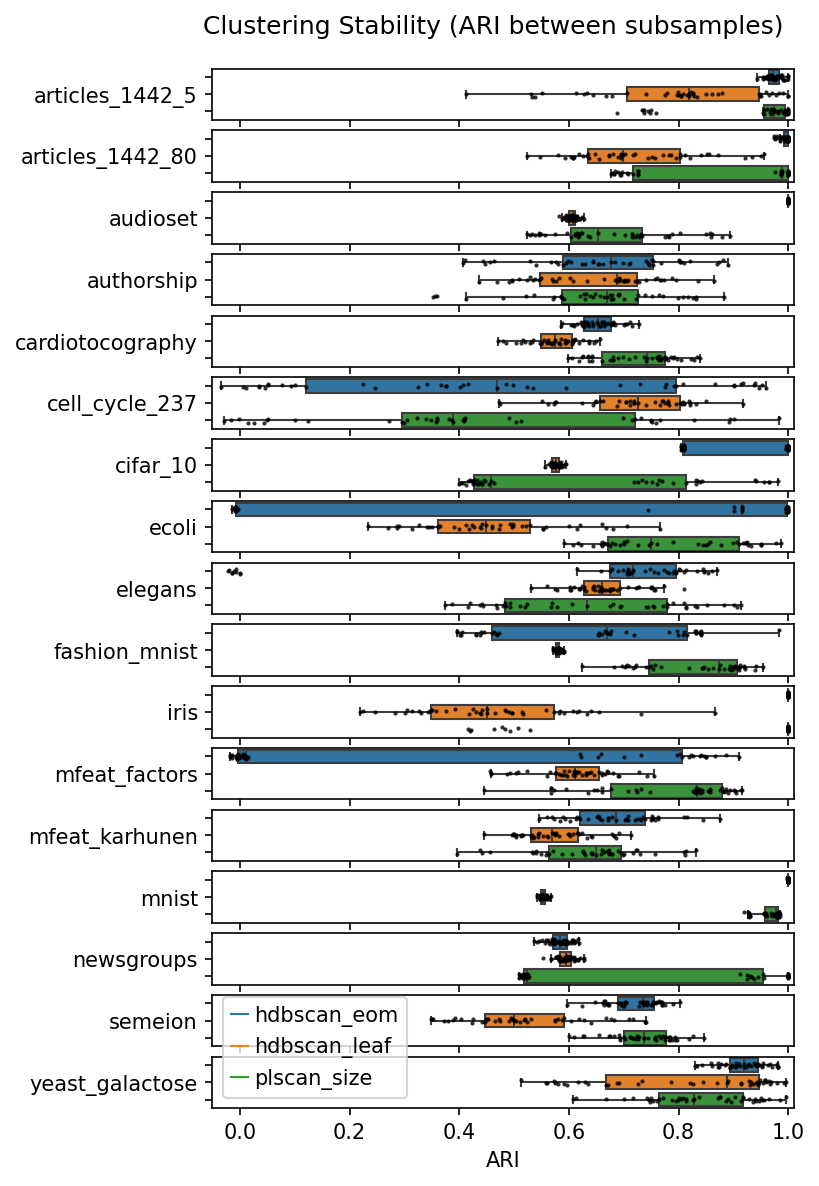

In [97]:
alg_ids = [a[0] for a in algorithms]
palette = plt.get_cmap("tab10").colors


plt.figure(figsize=(5, 9))
for i, dataset in enumerate(dataset_names):
    plt.subplot(len(dataset_names), 1, i + 1)
    sub_df = results_df.query("dataset == @dataset")
    sns.boxplot(
        data=sub_df,
        x="ari",
        y="algorithm",
        hue="algorithm",
        hue_order=alg_ids,
        order=alg_ids,
        palette=palette,
        legend=False,
        fliersize=0,
    )
    sns.stripplot(
        data=sub_df,
        x="ari",
        y="algorithm",
        order=alg_ids,
        legend=False,
        color="black",
        size=2,
        alpha=0.8,
        jitter=0.15,
    )
    plt.ylabel("")
    plt.yticks([0, 1, 2], ["", dataset, ""])
    plt.xlim(-0.05, 1.01)
    plt.xticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
    plt.xlabel("" if i < len(dataset_names) - 1 else "ARI")
    if i < len(dataset_names) - 1:
        plt.gca().set_xticklabels([])

plt.legend(
    handles=[
        plt.Line2D([0], [0], color=palette[j], lw=1, label=n)
        for j, n in enumerate(alg_ids)
    ],
    loc="lower left",
    handlelength=0.8,
    columnspacing=0.6,
    handletextpad=0.3,
)
plt.suptitle("Clustering Stability (ARI between subsamples)", y=0.92)
plt.show()

Aggregated per algorithm:

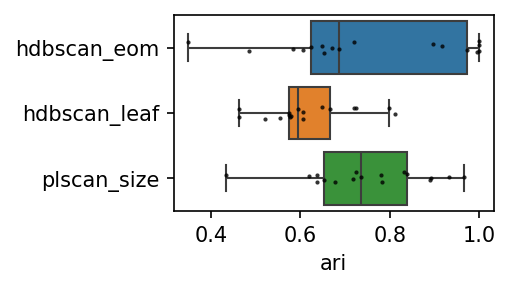

In [98]:
plot_df = results_df.groupby(["dataset", "algorithm"])["ari"].agg("mean").reset_index()
sns.boxplot(
    data=plot_df,
    x="ari",
    y="algorithm",
    hue="algorithm",
    hue_order=alg_ids,
    order=alg_ids,
    palette=palette,
    legend=False,
    fliersize=0
)
sns.stripplot(
    data=plot_df,
    x="ari",
    y="algorithm",
    order=alg_ids,
    legend=False,
    color="black",
    size=2,
    alpha=0.8,
)
plt.ylabel("")
plt.show()